In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [2]:
df = pd.read_csv("Unemployment in India.csv")

print(df.head())


           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
None


In [4]:
print(df.isnull().sum())

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [5]:
df.columns = df.columns.str.strip()

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.dropna(inplace=True)

In [8]:
df.rename(columns={
    'Region':'State',
    'Estimated Unemployment Rate (%)':'Unemployment Rate',
    'Estimated Employed':'Employed',
    'Estimated Labour Participation Rate (%)':'Labour Participation Rate'
}, inplace=True)


In [9]:
df['Date'] = pd.to_datetime(df['Date'])


C:\Users\Dell\AppData\Local\Temp\ipykernel_16708\3386729631.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [10]:
df['Date'] = pd.to_datetime(df['Date'])

In [11]:
print(df.head())


            State       Date Frequency  Unemployment Rate    Employed  \
0  Andhra Pradesh 2019-05-31   Monthly               3.65  11999139.0   
1  Andhra Pradesh 2019-06-30   Monthly               3.05  11755881.0   
2  Andhra Pradesh 2019-07-31   Monthly               3.75  12086707.0   
3  Andhra Pradesh 2019-08-31   Monthly               3.32  12285693.0   
4  Andhra Pradesh 2019-09-30   Monthly               5.17  12256762.0   

   Labour Participation Rate   Area  
0                      43.24  Rural  
1                      42.05  Rural  
2                      43.50  Rural  
3                      43.97  Rural  
4                      44.68  Rural  


In [12]:
print(df.describe())

                                Date  Unemployment Rate      Employed  \
count                            740         740.000000  7.400000e+02   
mean   2019-12-12 18:36:58.378378496          11.787946  7.204460e+06   
min              2019-05-31 00:00:00           0.000000  4.942000e+04   
25%              2019-08-31 00:00:00           4.657500  1.190404e+06   
50%              2019-11-30 00:00:00           8.350000  4.744178e+06   
75%              2020-03-31 00:00:00          15.887500  1.127549e+07   
max              2020-06-30 00:00:00          76.740000  4.577751e+07   
std                              NaN          10.721298  8.087988e+06   

       Labour Participation Rate  
count                 740.000000  
mean                   42.630122  
min                    13.330000  
25%                    38.062500  
50%                    41.160000  
75%                    45.505000  
max                    72.570000  
std                     8.111094  


In [13]:
avg = df.groupby('State')['Unemployment Rate'].mean().sort_values(ascending=False)

In [14]:
print(avg)

State
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Unemployment Rate, dtype: float64


In [15]:
plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

C:\Users\Dell\AppData\Local\Temp\ipykernel_16708\3137673396.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: ylabel='State'>

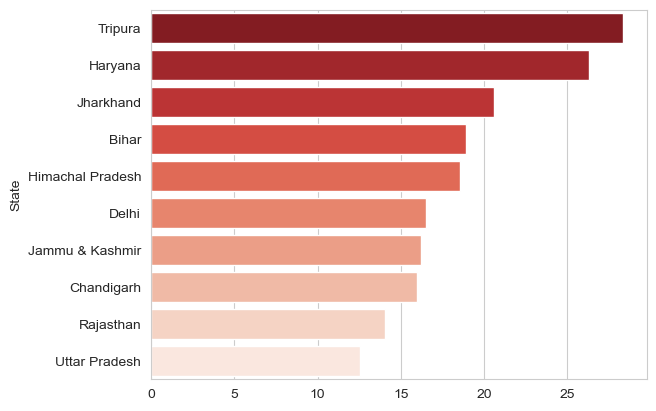

In [16]:
sns.barplot(
    x=avg.head(10).values,
    y=avg.head(10).index,
    palette="Reds_r"
)

<Axes: ylabel='State'>

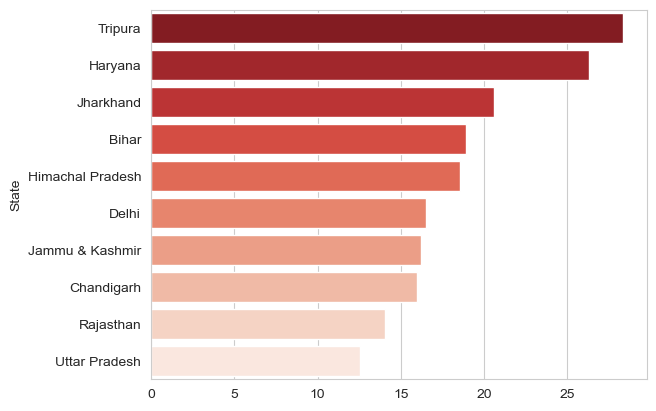

In [17]:
sns.barplot(
    x=avg.head(10).values,
    y=avg.head(10).index,
    hue=avg.head(10).index,
    palette="Reds_r",
    legend=False
)

Text(0.5, 1.0, 'Top 10 States with Highest Average Unemployment')

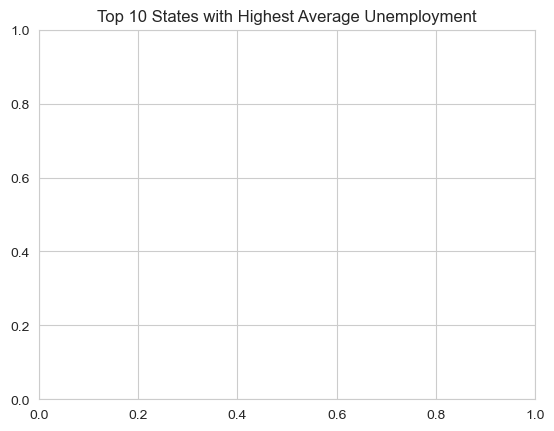

In [18]:
plt.title("Top 10 States with Highest Average Unemployment")

Text(0.5, 0, 'Unemployment Rate (%)')

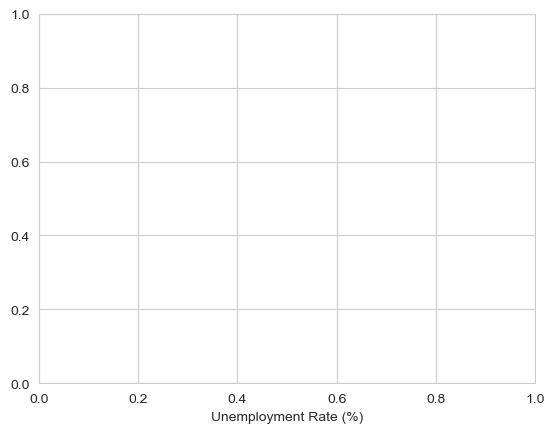

In [19]:
plt.xlabel("Unemployment Rate (%)")

Text(0, 0.5, 'State')

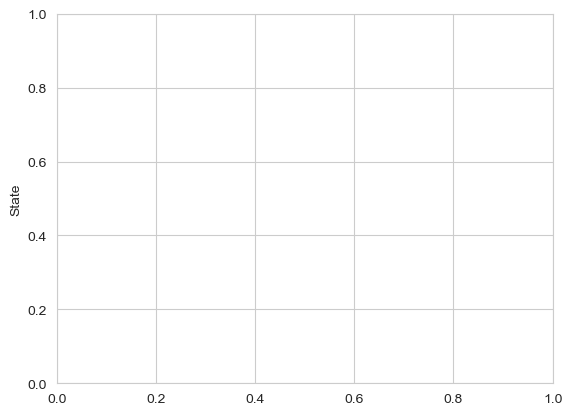

In [20]:
plt.ylabel("State")

In [21]:
plt.show()

In [22]:
monthly = df.groupby(df['Date'].dt.month_name())['Unemployment Rate'].mean()


In [23]:
order = ["January","February","March","April","May","June",
         "July","August","September","October","November","December"]

In [24]:
monthly = monthly.reindex(order)


In [25]:
plt.figure(figsize=(12,5))


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Axes: xlabel='Date'>

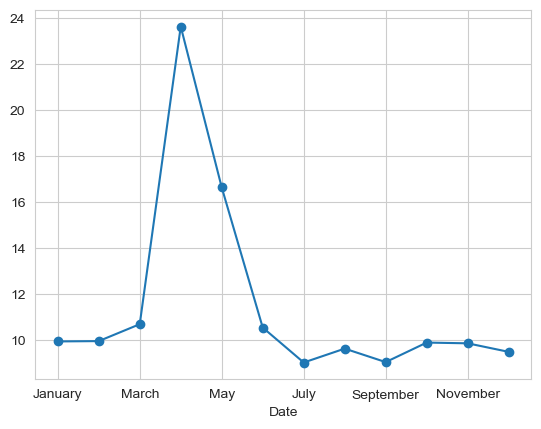

In [26]:
monthly.plot(marker='o')

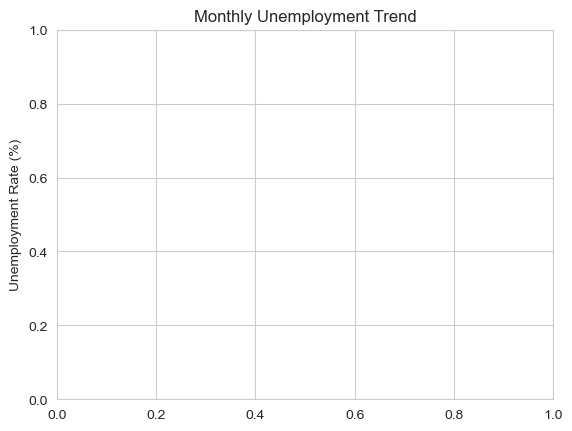

In [27]:
plt.title("Monthly Unemployment Trend")
plt.ylabel("Unemployment Rate (%)")

plt.show()

In [28]:
covid = df[df['Date'] >= "2020-03-01"]

plt.figure(figsize=(12,5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Axes: xlabel='Date', ylabel='Unemployment Rate'>

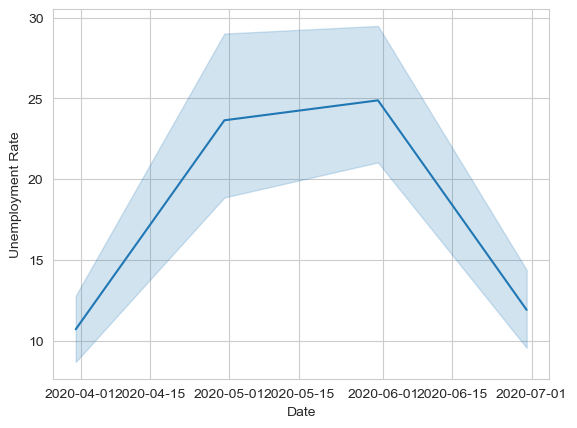

In [29]:
sns.lineplot(
    data=covid,
    x='Date',
    y='Unemployment Rate'
)

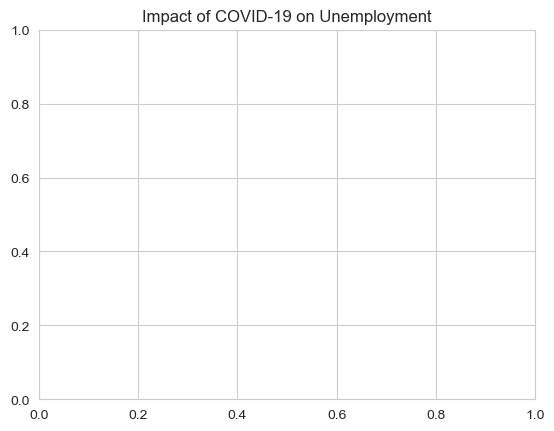

In [30]:
plt.title("Impact of COVID-19 on Unemployment")

plt.show()

In [31]:
pivot = df.pivot_table(
    values='Unemployment Rate',
    index='State',
    columns=df['Date'].dt.month_name(),
    aggfunc='mean'
)


In [32]:
plt.figure(figsize=(15,10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Axes: xlabel='Date', ylabel='State'>

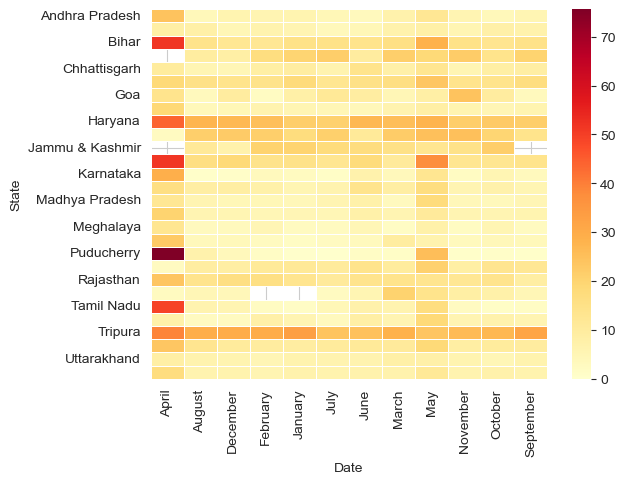

In [33]:
sns.heatmap(
    pivot,
    cmap="YlOrRd",
    linewidths=0.5
)

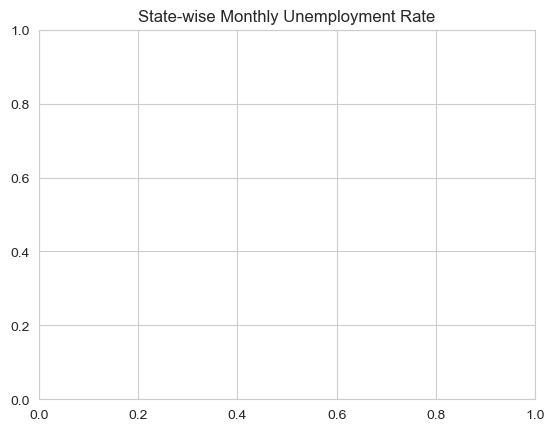

In [34]:
plt.title("State-wise Monthly Unemployment Rate")

plt.show()

In [35]:
plt.figure(figsize=(7,5))

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Axes: >

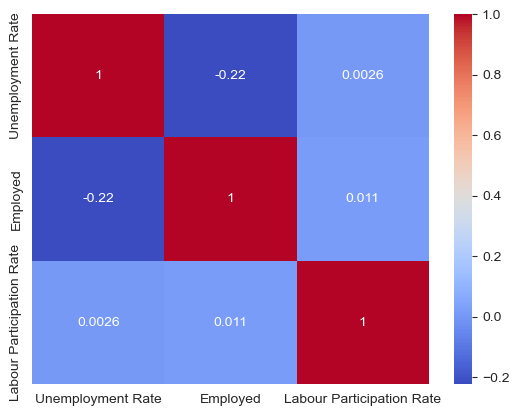

In [36]:
sns.heatmap(
    df[['Unemployment Rate',
        'Employed',
        'Labour Participation Rate']].corr(),
    annot=True,
    cmap="coolwarm"
)

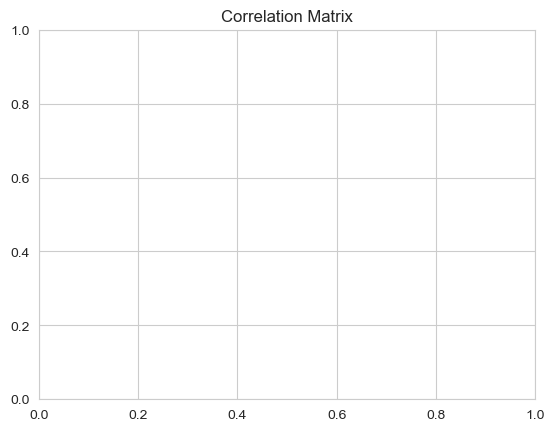

In [37]:
plt.title("Correlation Matrix")

plt.show()

In [38]:
top = avg.head(5)


In [39]:
plt.figure(figsize=(7,7))

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

([<matplotlib.patches.Wedge at 0x267eedc6ba0>,
 [Text(0.7738807247394766, 0.78173436912848, 'Tripura'),
  Text(-0.7440766819202856, 0.810154239279471, 'Haryana'),
  Text(-0.9762714075649308, -0.5068472538854176, 'Jharkhand'),
  Text(0.010416841975287154, -1.099950675895634, 'Bihar'),
  Text(0.9562743403968842, -0.5436353427606636, 'Himachal Pradesh')],
 [Text(0.42211675894880535, 0.4264005649791709, '25.2%'),
  Text(-0.40586000832015573, 0.4419023123342568, '23.3%'),
  Text(-0.5325116768535986, -0.27646213848295503, '18.3%'),
  Text(0.005681913804702084, -0.599973095943073, '16.8%'),
  Text(0.5216041856710276, -0.29652836877854377, '16.5%')])

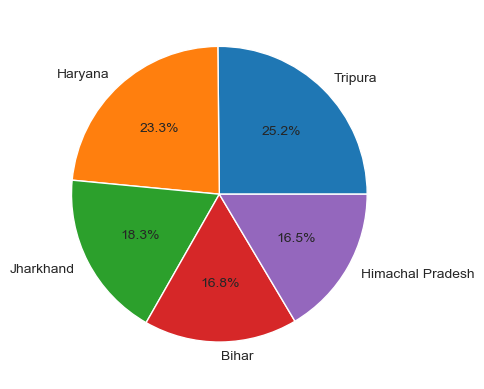

In [40]:
plt.pie(
    top.values,
    labels=top.index,
    autopct='%1.1f%%'
)

Text(0.5, 1.0, 'Top 5 Highest Unemployment States')

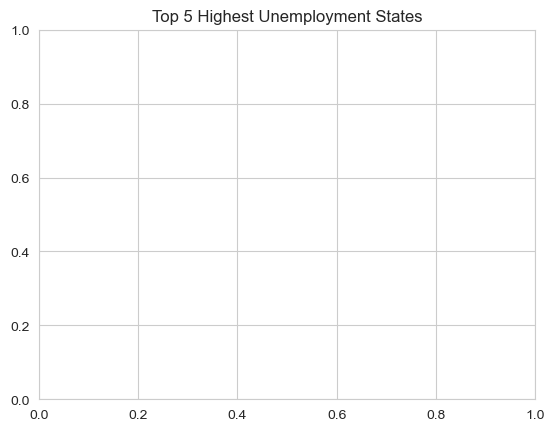

In [41]:
plt.title("Top 5 Highest Unemployment States")

In [42]:
plt.show()

In [43]:
print("\nKEY INSIGHTS\n")


KEY INSIGHTS



In [44]:
print("1. COVID-19 caused a sharp increase in unemployment.")

1. COVID-19 caused a sharp increase in unemployment.


In [45]:
print("2. Several states experienced significantly higher unemployment than others.")

2. Several states experienced significantly higher unemployment than others.


In [46]:
print("3. Monthly analysis shows seasonal variations.")

3. Monthly analysis shows seasonal variations.


In [47]:
print("4. Labour participation influences unemployment trends.")

4. Labour participation influences unemployment trends.


In [48]:
print("5. Government employment programs can target high-unemployment regions.")

5. Government employment programs can target high-unemployment regions.
